# Trajectory Distribution Fuzzing in Highway Roundabout

This notebook demonstrates trajectory distribution fuzzing for the HighwayEnv roundabout environment.

**Key Components** (now in `src/` modules):
- `ScenarioParams`: Dataclass for configurable observation, action, and environment disturbances
- `SimulatedEnv`: Custom roundabout environment with fuzzable parameters
- `ScenarioFuzzer`: Class for rollouts and finding critical failure scenarios

**Usage**: Create a `ScenarioFuzzer` with env and model, then call `fuzzer.rollout()` or `fuzzer.optimize()`

In [1]:
# Uncomment to install dependencies
# !pip install gymnasium stable_baselines3 opencv-python highway_env torch

In [2]:
# Use dummy video driver to prevent window from appearing
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import gymnasium as gym
from gymnasium.wrappers import RecordVideo

from gymnasium.envs.registration import register
from stable_baselines3 import DQN

import numpy as np

# Import from src modules (auto-registers SimulatedEnv-v0)
from src import (
    ScenarioParams,
    GaussianMixtureParam,
    NormalParam,
    ProbabilityParam,
    BetaParam,
    NOMINAL,
    SQRT_2,
    SimulatedEnv,
    ScenarioFuzzer,
    FuzzerConfig,
    PARAM_NAMES,
    compute_robustness,
    weights_from_vector,
)

objc[537]: Class SDLApplication is implemented in both /Users/williamzhang/Documents/StanfordRoundabout/env/lib/python3.9/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11b3a0890) and /Users/williamzhang/Documents/StanfordRoundabout/env/lib/python3.9/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x13f87d2c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[537]: Class SDLAppDelegate is implemented in both /Users/williamzhang/Documents/StanfordRoundabout/env/lib/python3.9/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x11b3a08e0) and /Users/williamzhang/Documents/StanfordRoundabout/env/lib/python3.9/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x13f87d318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[537]: Class SDLTranslatorResponder is implemented in both /Users/williamzhang/Documents/StanfordRoundabout/env/lib/python3.9/site-p

In [3]:
# Register the environment when module is imported
register(
    id="SimulatedEnv-v0",
    entry_point="src.simulated_env:SimulatedEnv",
)

In [4]:
# Define scenario parameters (customize as needed)
setup = ScenarioParams(
    # Observation disturbances
    initial_position_x=GaussianMixtureParam(
        p=[1.0], 
        mu=[0.0, 0.0], 
        sigma=[0.005, 0.005]
    ),
    initial_position_y=GaussianMixtureParam(
        p=[1.0], 
        mu=[0.0, 0.0], 
        sigma=[0.005, 0.005]
    ),
    velocity_x=GaussianMixtureParam(
        p=[1.0],
        mu=[0.0, 0.0],
        sigma=[SQRT_2 * 0.005 / 0.1, SQRT_2 * 0.005 / 0.1]
    ),
    velocity_y=GaussianMixtureParam(
        p=[1.0],
        mu=[0.0, 0.0],
        sigma=[SQRT_2 * 0.005 / 0.1, SQRT_2 * 0.005 / 0.1]
    ),
    # Action disturbances
    high_lvl_ctrl_noise=ProbabilityParam(p=[0.0]),
    initial_speed=NormalParam(mu=8.0, sigma=0.5),
    initial_heading=ProbabilityParam(p=[0.33, 0.33, 0.33]),
    # Environment disturbances
    politeness=BetaParam(ab=[1, 1]),  # uniform distribution
    other_vehicle_speed=NormalParam(mu=16.0, sigma=2.0),
    entering_vehicle_position=GaussianMixtureParam(
        p=[1.0],
        mu=[5.0, 5.0],  # tip: mu=100.0 can cause more crashes
        sigma=[2.0, 2.0]
    )
)

In [5]:
TRAIN = False

# Create the environment
env = gym.make("SimulatedEnv-v0", render_mode="rgb_array", scenario_params=setup)
obs, info = env.reset()

# Create the model
model = DQN(
    "MlpPolicy",
    env,
    policy_kwargs=dict(net_arch=[256, 256]),
    learning_rate=5e-4,
    buffer_size=15000,
    learning_starts=200,
    batch_size=32,
    gamma=0.8,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=50,
    verbose=1,
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [6]:
# Train the model (if needed)
if TRAIN:
    model.learn(total_timesteps=int(2e4))
    model.save("roundabout_dqn/model")
    del model

In [7]:
# Load trained model
model = DQN.load("roundabout_dqn/model.zip", env=env, device="cpu")

# Configure environment
env.unwrapped.config["simulation_frequency"] = 15
env.unwrapped.config.update({
    "observation": {
        "type": "Kinematics",
        "absolute": True,
        "features_range": {
            "x": [-100, 100],
            "y": [-100, 100],
            "vx": [-15, 15],
            "vy": [-15, 15],
        },
        "vehicles_count": 5,
    },
})

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [8]:
# Record videos to disk (saved to roundabout_dqn/videos/, not displayed)
RECORD_VIDEO = True
if RECORD_VIDEO:
    env = RecordVideo(
        env, video_folder="roundabout_dqn/videos/", episode_trigger=lambda e: True
    )
    env.unwrapped.set_record_video_wrapper(env)

# Robustness weights
robustness_weights = weights_from_vector([0.2042, 0.1982, 0.4393, 0.0111, 0.1471])

/Users/williamzhang/Documents/StanfordRoundabout/env/lib/python3.9/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /Users/williamzhang/Documents/StanfordRoundabout/roundabout_dqn/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [9]:
# Create fuzzer for rollouts
fuzzer = ScenarioFuzzer(env, model, robustness_weights=robustness_weights)

# Run rollouts and collect metrics
N_ROLLOUTS = 50  # increase for better statistics

logs = []
for i in range(N_ROLLOUTS):
    result = fuzzer.rollout()
    logs.append(result)
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1}/{N_ROLLOUTS} rollouts")

print(f"\nCollected {len(logs)} rollouts")

Completed 10/50 rollouts
Completed 20/50 rollouts
Completed 30/50 rollouts
Completed 40/50 rollouts
Completed 50/50 rollouts

Collected 50 rollouts


## Plot Log Probability vs Robustness Factors

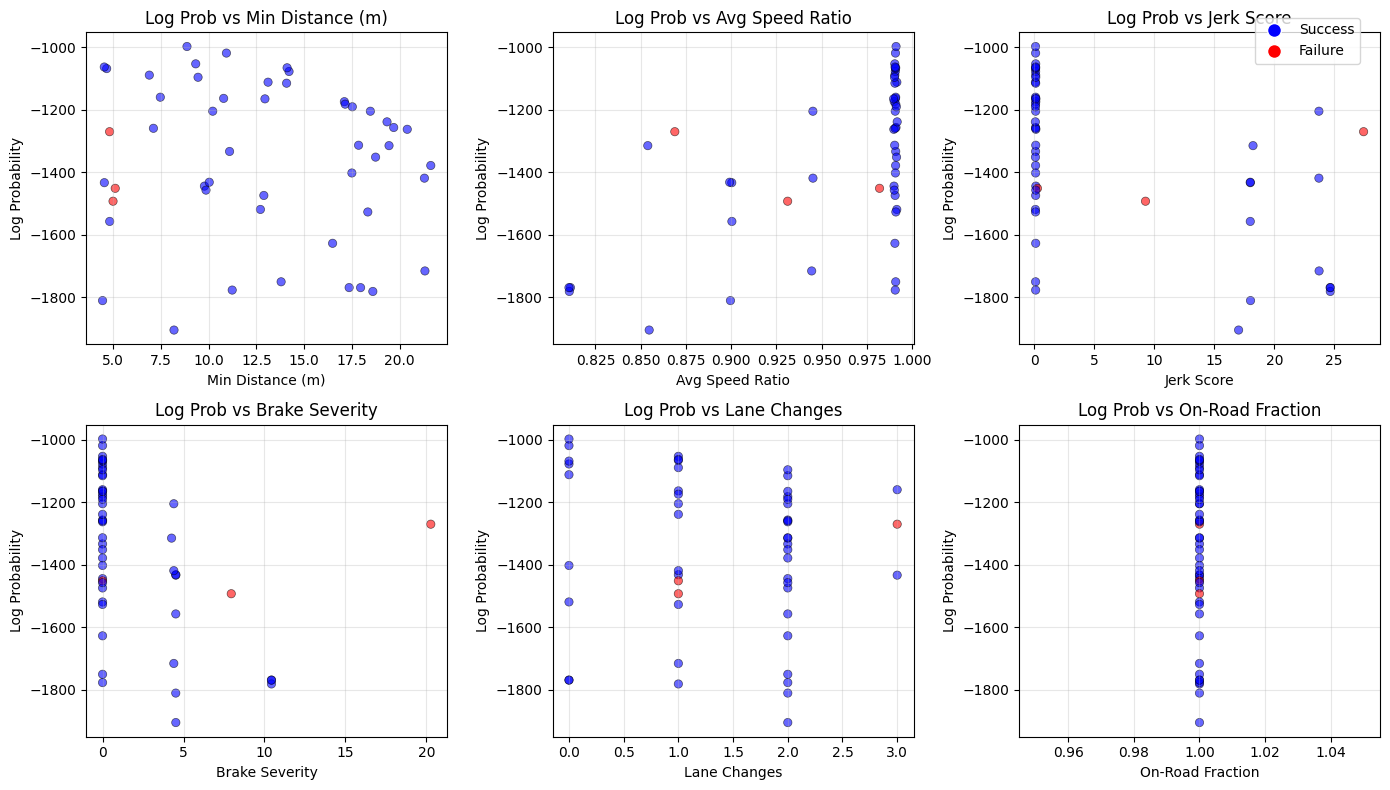


Summary: 3/50 failures (6.0%)
Log prob range: [-1904.1, -996.8]


In [14]:
import matplotlib.pyplot as plt

# Extract data from logs
log_probs = [r["log_prob"] for r in logs]
failures = [r["is_failure"] for r in logs]

# Separate by outcome
success_logs = [r for r in logs if not r["is_failure"]]
failure_logs = [r for r in logs if r["is_failure"]]

# Metric names to plot
metric_names = ["min_distance", "avg_speed_ratio", "jerk_score", "brake_severity", "lane_changes", "on_road_frac"]
metric_labels = ["Min Distance (m)", "Avg Speed Ratio", "Jerk Score", "Brake Severity", "Lane Changes", "On-Road Fraction"]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (metric, label) in enumerate(zip(metric_names, metric_labels)):
    ax = axes[idx]
    
    success_vals = [r["metrics"][metric] for r in success_logs]
    failure_vals = [r["metrics"][metric] for r in failure_logs]
    
    # Plot overlapping histograms
    if success_vals:
        ax.hist(success_vals, bins=15, alpha=0.6, label="Success", color="blue", edgecolor="black")
    if failure_vals:
        ax.hist(failure_vals, bins=15, alpha=0.6, label="Failure", color="red", edgecolor="black")
    
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
n_failures = len(failure_logs)
print(f"\nSummary: {n_failures}/{len(logs)} failures ({100*n_failures/len(logs):.1f}%)")
print(f"Log prob range: [{min(log_probs):.1f}, {max(log_probs):.1f}]")

## Fuzzing for Critical Failures

Use `ScenarioFuzzer` to find scenario parameters that minimize robustness while keeping scenarios plausible.

In [11]:
# Update fuzzer config for optimization
fuzzer.config = FuzzerConfig(
    n_samples=3,           # rollouts per evaluation
    log_prob_weight=0.01,  # penalty for implausible scenarios
    verbose=True,
)

# Show parameter bounds
print("Parameter bounds:")
for name, (lo, hi), val in zip(PARAM_NAMES, fuzzer.config.bounds, fuzzer.config.initial_guess):
    print(f"  {name}: [{lo}, {hi}], initial={val}")

Parameter bounds:
  entering_vehicle_mu: [0, 150], initial=5.0
  other_vehicle_speed: [10, 25], initial=16.0
  ctrl_noise_p: [0.0, 0.5], initial=0.0
  initial_speed_mu: [0.0, 16.0], initial=8.0
  politeness_alpha: [0.1, 10.0], initial=1.0
  politeness_beta: [0.1, 10.0], initial=1.0
  pos_x_sigma: [0.001, 0.1], initial=0.005
  pos_y_sigma: [0.001, 0.1], initial=0.005
  vel_x_sigma: [0.001, 0.1], initial=0.005
  vel_y_sigma: [0.001, 0.1], initial=0.005


In [12]:
# Run optimization (WARNING: this can take a while)
# Uncomment to run

# result = fuzzer.optimize(method="L-BFGS-B", maxiter=50)
# print(f"\nOptimization finished: {result.message}")
# print(f"Critical failure parameters:")
# for name, val in fuzzer.get_params_dict(result.x).items():
#     print(f"  {name}: {val:.4f}")
# print(f"\nBest result: {fuzzer.best_result}")

In [13]:
env.close()